# TASK 2 : Credit Card Fraud Detection

**Goal:** Build a model to detect fraudulent credit card transactions.

We will use a simulated credit card transactions dataset (Sparkov) and try three simple algorithms:
- Logistic Regression
- Decision Tree
- Random Forest

We will compare them using accuracy, classification report, and a confusion matrix.



## Step 1: Import the libraries we need

We are using pandas for handling data, matplotlib/seaborn for plotting, and scikit-learn for the ML models.

In [2]:
# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation tools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Just to make plots look a bit nicer
sns.set_style('whitegrid')

## Step 2: Load the dataset

The dataset already comes split into a training file and a testing file, so we don't need to split it ourselves.

If your dataset is very large and Colab feels slow, you can set `SAMPLE_SIZE` to a smaller number (like 50000) to speed things up. Set it to `None` to use the full dataset.

In [3]:
# Set this to a number (e.g. 50000) to work with a smaller sample, or None to use everything
SAMPLE_SIZE = 50000

# Load the training and testing CSV files
train_df = pd.read_csv('/content/fraudTrain.csv', index_col=0)
test_df = pd.read_csv('/content/fraudTest.csv', index_col=0)

# If SAMPLE_SIZE is set, take a random sample so the models run faster
if SAMPLE_SIZE is not None:
    train_df = train_df.sample(n=SAMPLE_SIZE, random_state=42)
    test_df = test_df.sample(n=min(SAMPLE_SIZE, len(test_df)), random_state=42)

print('Training data shape:', train_df.shape)
print('Testing data shape:', test_df.shape)

train_df.head()

Training data shape: (50000, 22)
Testing data shape: (50000, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
435634,2019-07-14 00:49:47,30273037698427,fraud_Rodriguez Group,gas_transport,50.31,Andrew,Patterson,M,06959 Stephen Branch Suite 246,Thida,...,35.5762,-91.4539,111.0,Careers information officer,2000-06-13,088f49e0448eb5316c51b7b868f901eb,1.342227e+09,35.913717,-91.754590,0.0
857339,2019-12-16 17:20:12,5540636818935089,fraud_Price Inc,shopping_net,1.25,Kenneth,Foster,M,329 Michael Extension,Lawrence,...,42.6911,-71.1605,76383.0,Geoscientist,1985-04-04,2a683d1e9864ec4799382c2592395125,1.355678e+09,42.382032,-72.050128,0.0
293089,2019-05-24 12:37:05,213148039875802,fraud_Wuckert-Goldner,home,72.96,Jill,Jacobs,F,034 Kimberly Mountains,Brandon,...,27.9551,-82.2966,79613.0,Environmental consultant,1978-11-30,74908551dedbb4cacaa3fd312b3c8a26,1.337863e+09,27.025163,-81.441117,0.0
357307,2019-06-16 04:12:13,345832460465610,fraud_Bartoletti-Wunsch,gas_transport,69.61,Jason,Mcmahon,M,6385 Donald Square Suite 429,Springfield,...,38.8029,-77.2116,104396.0,Production engineer,1950-11-20,58786d0323366d3eab1e9f9120d24a9d,1.339820e+09,39.283357,-77.478877,0.0
514921,2019-08-11 03:10:51,180065479077096,fraud_McGlynn-Jaskolski,misc_pos,2.10,Krystal,Gamble,F,47152 Clayton Burg,Manchester,...,39.6747,-76.8941,11751.0,Clinical research associate,1964-02-15,3db3f8600ba06a2ab11de03cd7a45a66,1.344655e+09,40.577169,-76.991167,0.0


## Step 3: Explore the data a little

It's always a good idea to look at the data before building a model. Let's check for missing values and see how balanced the two classes (fraud vs not fraud) are.

In [4]:
# Check basic info about the training data
print(train_df.info())

# Check for missing values
print('\nMissing values in each column:')
print(train_df.isnull().sum())

# Check how many fraud vs non-fraud transactions we have
print('\nClass distribution (0 = legit, 1 = fraud):')
print(train_df['is_fraud'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 435634 to 385529
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  50000 non-null  object 
 1   cc_num                 50000 non-null  int64  
 2   merchant               50000 non-null  object 
 3   category               50000 non-null  object 
 4   amt                    50000 non-null  float64
 5   first                  50000 non-null  object 
 6   last                   50000 non-null  object 
 7   gender                 50000 non-null  object 
 8   street                 50000 non-null  object 
 9   city                   50000 non-null  object 
 10  state                  50000 non-null  object 
 11  zip                    50000 non-null  int64  
 12  lat                    50000 non-null  float64
 13  long                   50000 non-null  float64
 14  city_pop               50000 non-null  float64
 15  j

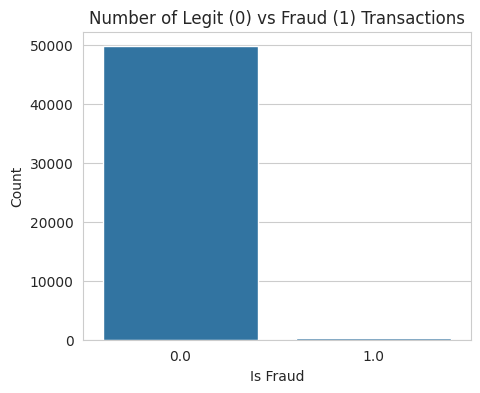

In [5]:
# Plot the class distribution so we can SEE the imbalance
plt.figure(figsize=(5, 4))
sns.countplot(x='is_fraud', data=train_df)
plt.title('Number of Legit (0) vs Fraud (1) Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

# Note: Fraud cases are usually a very small percentage of all transactions.
# This is called 'class imbalance' and it's normal for fraud detection problems.

## Step 4: Select useful features and clean the data

The dataset has many columns. Some of them (like names, street address, transaction ID) don't really help the model predict fraud, so we will drop them.

We will keep columns like: transaction amount, category, location details, city population, and the customer's age (calculated from date of birth).

In [6]:
# Make a copy so we don't accidentally change the original data
train_data = train_df.copy()
test_data = test_df.copy()

# Convert date of birth into an age (in years) - this can be a useful feature
train_data['dob'] = pd.to_datetime(train_data['dob'])
test_data['dob'] = pd.to_datetime(test_data['dob'])

train_data['age'] = 2020 - train_data['dob'].dt.year
test_data['age'] = 2020 - test_data['dob'].dt.year

# Columns we don't need for the model
columns_to_drop = [
    'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
    'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num', 'unix_time'
]

train_data = train_data.drop(columns=columns_to_drop)
test_data = test_data.drop(columns=columns_to_drop)

train_data.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,age
435634,gas_transport,50.31,M,35.5762,-91.4539,111.0,35.913717,-91.754590,0.0,20
857339,shopping_net,1.25,M,42.6911,-71.1605,76383.0,42.382032,-72.050128,0.0,35
293089,home,72.96,F,27.9551,-82.2966,79613.0,27.025163,-81.441117,0.0,42
357307,gas_transport,69.61,M,38.8029,-77.2116,104396.0,39.283357,-77.478877,0.0,70
514921,misc_pos,2.10,F,39.6747,-76.8941,11751.0,40.577169,-76.991167,0.0,56


In [7]:

# I use LabelEncoder to convert these text categories into numbers.

le_category = LabelEncoder()
le_gender = LabelEncoder()

# Fit the encoder on the training data categories, then apply to both train and test
train_data['category'] = le_category.fit_transform(train_data['category'])
test_data['category'] = le_category.transform(test_data['category'])

train_data['gender'] = le_gender.fit_transform(train_data['gender'])
test_data['gender'] = le_gender.transform(test_data['gender'])

train_data.head()

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,age
435634,2,50.31,1,35.5762,-91.4539,111.0,35.913717,-91.754590,0.0,20
857339,11,1.25,1,42.6911,-71.1605,76383.0,42.382032,-72.050128,0.0,35
293089,6,72.96,0,27.9551,-82.2966,79613.0,27.025163,-81.441117,0.0,42
357307,2,69.61,1,38.8029,-77.2116,104396.0,39.283357,-77.478877,0.0,70
514921,9,2.10,0,39.6747,-76.8941,11751.0,40.577169,-76.991167,0.0,56


## Step 5: Split into features (X) and target (y)

`is_fraud` is what we want to predict, so that becomes our target `y`. Everything else becomes our features `X`.

In [8]:
# Features (everything except the target column)
X_train = train_data.drop(columns=['is_fraud'])
X_test = test_data.drop(columns=['is_fraud'])

# Target column (what we want to predict)
y_train = train_data['is_fraud']
y_test = test_data['is_fraud']

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (50000, 9)
X_test shape: (50000, 9)


## Step 6: Model 1 - Logistic Regression

Logistic Regression is a simple and fast model, often used as a good starting point for classification problems.

In [9]:
# Create and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test data
log_reg_predictions = log_reg_model.predict(X_test)

# Check accuracy
log_reg_accuracy = accuracy_score(y_test, log_reg_predictions)
print('Logistic Regression Accuracy:', log_reg_accuracy)

# Print a detailed classification report (precision, recall, f1-score)
print('\nClassification Report:')
print(classification_report(y_test, log_reg_predictions))

Logistic Regression Accuracy: 0.99534

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49805
           1       0.00      0.00      0.00       195

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.99      1.00      0.99     50000



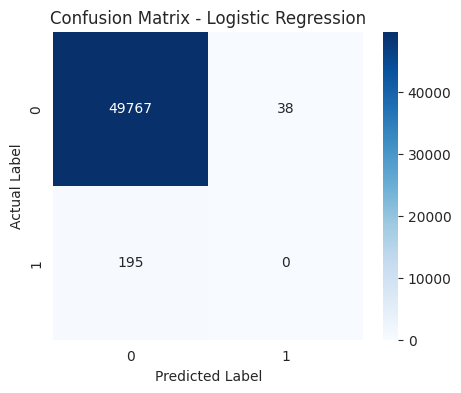

In [10]:
# Plot the confusion matrix for Logistic Regression
log_reg_cm = confusion_matrix(y_test, log_reg_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(log_reg_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Step 7: Model 2 - Decision Tree

A Decision Tree splits the data based on feature values to make predictions. It's easy to understand and visualize.

In [11]:
# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test data
dt_predictions = dt_model.predict(X_test)

# Check accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)
print('Decision Tree Accuracy:', dt_accuracy)

# Print a detailed classification report
print('\nClassification Report:')
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.99608

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49805
           1       0.50      0.50      0.50       195

    accuracy                           1.00     50000
   macro avg       0.75      0.75      0.75     50000
weighted avg       1.00      1.00      1.00     50000



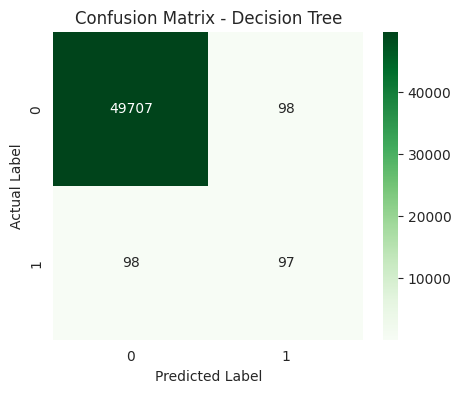

In [12]:
# Plot the confusion matrix for Decision Tree
dt_cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Step 8: Model 3 - Random Forest

Random Forest builds many decision trees and combines their results. It usually performs better than a single decision tree.

In [13]:
# Create and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_predictions = rf_model.predict(X_test)

# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print('Random Forest Accuracy:', rf_accuracy)

# Print a detailed classification report
print('\nClassification Report:')
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.99732

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49805
           1       0.77      0.45      0.57       195

    accuracy                           1.00     50000
   macro avg       0.88      0.73      0.78     50000
weighted avg       1.00      1.00      1.00     50000



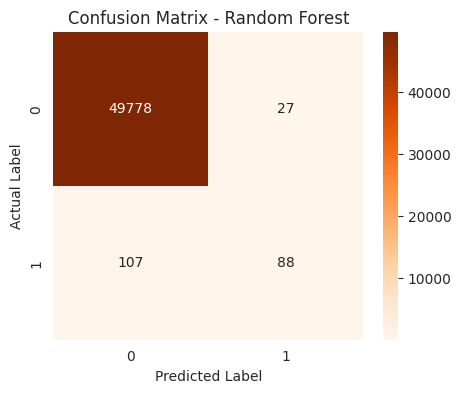

In [14]:
# Plot the confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## Step 9: Compare all three models

Let's put the accuracy of all three models side by side in a simple bar chart.

Model Comparison:
Logistic Regression: 0.9953
Decision Tree: 0.9961
Random Forest: 0.9973


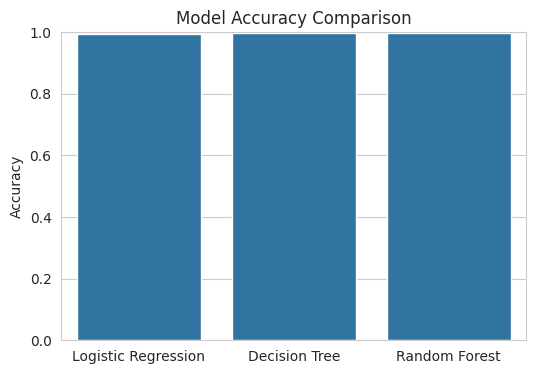

In [15]:
# Put all model names and their accuracies into simple lists
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
model_accuracies = [log_reg_accuracy, dt_accuracy, rf_accuracy]

# Print a simple summary table
print('Model Comparison:')
for name, acc in zip(model_names, model_accuracies):
    print(f'{name}: {acc:.4f}')

# Plot a bar chart comparing accuracies
plt.figure(figsize=(6, 4))
sns.barplot(x=model_names, y=model_accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()